In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [57]:
from facter.utils import setup_logging, generate_recommendations, evaluate_at_k_from_lists, evaluate_valid_at_k
from facter.data import DatasetLoader


### Dataset: MovieLens

In [58]:
# Full Dataset MovieLens
logger = setup_logging()
loader = DatasetLoader('ml-1m')
full_ml = loader.prepare_prompts().dropna().reset_index(drop=True)

Building sequences (ml-1m): 100%|██████████| 6040/6040 [00:03<00:00, 1726.98it/s]


In [62]:
# Number of samples in full MovieLens
len(full_ml)

939809

In [59]:
full_ml.head()

,prompt,context,gender,age,occupation,target_mid,target_title
0,User profile (audit only):\n- gender: F\n- age...,"Watch history:\n1. Girl, Interrupted (1999)\n2...",F,Under 18,K-12 student,720,Wallace & Gromit: The Best of Aardman Animatio...
1,User profile (audit only):\n- gender: F\n- age...,Watch history:\n1. Back to the Future (1985)\n...,F,Under 18,K-12 student,260,Star Wars: Episode IV - A New Hope (1977)
2,User profile (audit only):\n- gender: F\n- age...,Watch history:\n1. Titanic (1997)\n2. Cinderel...,F,Under 18,K-12 student,919,"Wizard of Oz, The (1939)"
3,User profile (audit only):\n- gender: F\n- age...,Watch history:\n1. Cinderella (1950)\n2. Meet ...,F,Under 18,K-12 student,608,Fargo (1996)
4,User profile (audit only):\n- gender: F\n- age...,Watch history:\n1. Meet Joe Black (1998)\n2. L...,F,Under 18,K-12 student,2692,Run Lola Run (Lola rennt) (1998)


In [60]:
# Number of target titles in the full MovieLens
len(full_ml['target_title'].drop_duplicates())

3668

In [ ]:
# Sampled dataset
ml = pd.read_csv('data_preprocessed/ml-1m_2500.csv')
ml_train = pd.read_csv('data_preprocessed/ml-1m_2500_train.csv')
ml_test = pd.read_csv('data_preprocessed/ml-1m_2500_test.csv')

In [47]:
ml.head()

,prompt,context,gender,age,occupation,target_mid,target_title
0,User profile (audit only):\n- gender: M\n- age...,Watch history:\n1. Independence Day (ID4) (199...,M,50-55,academic/educator,3022,"General, The (1927)"
1,User profile (audit only):\n- gender: F\n- age...,Watch history:\n1. Renaissance Man (1994)\n2. ...,F,25-34,college/grad student,333,Tommy Boy (1995)
2,User profile (audit only):\n- gender: M\n- age...,Watch history:\n1. Terms of Endearment (1983)\...,M,25-34,academic/educator,2245,Working Girl (1988)
3,User profile (audit only):\n- gender: M\n- age...,"Watch history:\n1. Spanish Prisoner, The (1997...",M,25-34,academic/educator,1748,Dark City (1998)
4,User profile (audit only):\n- gender: M\n- age...,Watch history:\n1. Shadowlands (1993)\n2. Fabu...,M,56+,writer,3224,Woman in the Dunes (Suna no onna) (1964)


In [48]:
# number of female users in MovieLens
print('number of female users:', len(ml[ml['gender']=='F']))
print('number of male users:', len(ml[ml['gender']=='M']))


number of female users: 597
number of male users: 1903


In [49]:
# number of distinct of occupations
print(len(list(ml['occupation'].drop_duplicates())))

21


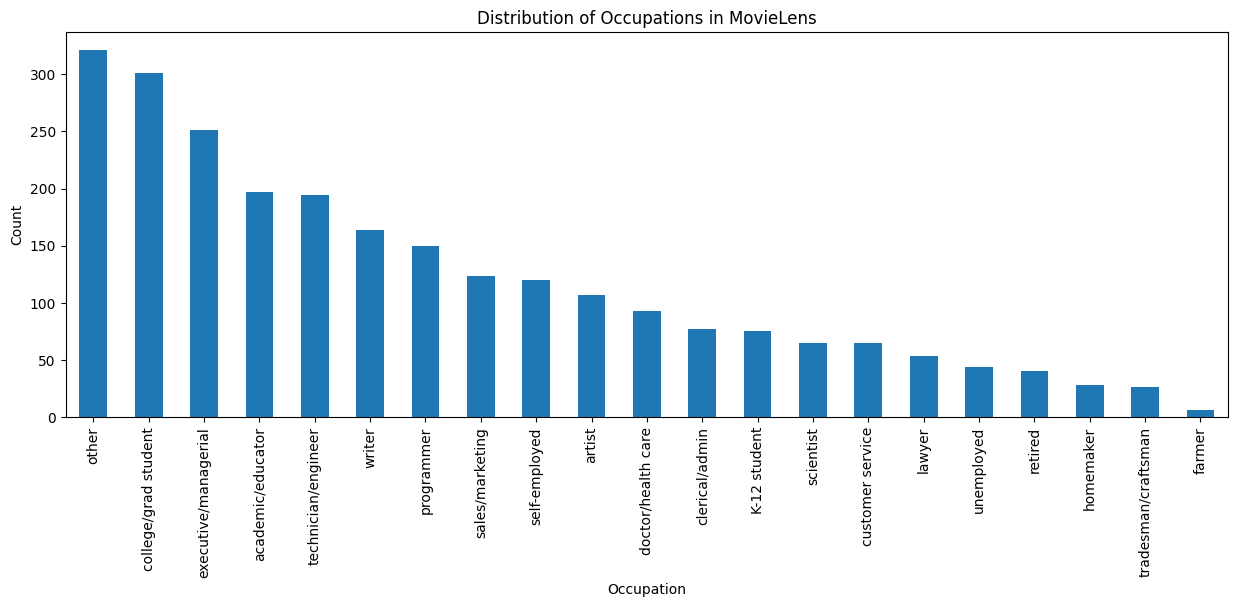

In [50]:
# Bar plot of occupations
counts = ml["occupation"].value_counts()
plt.figure(figsize=(15,5))
counts.plot(kind='bar')
plt.xlabel("Occupation")
plt.ylabel("Count")
plt.title("Distribution of Occupations in MovieLens")
plt.show()

In [51]:
# number of distinct target titles
print(len(list(ml['target_title'].drop_duplicates())))

1297


In [ ]:
# number of unique combinations gender-age-occupation in MovieLens sampled
group_counts = ml[['gender', 'age', 'occupation']].value_counts()
group_counts

gender  age       occupation          
M       18-24     college/grad student    151
        25-34     other                   119
                  executive/managerial     89
                  college/grad student     79
                  programmer               74
                                         ... 
F       Under 18  artist                    1
        56+       self-employed             1
                  other                     1
                  sales/marketing           1
M       Under 18  sales/marketing           1
Name: count, Length: 198, dtype: int64

In [52]:
# number of unique combinations gender-age-occupation in calibration set
group_counts_train = ml_train[['gender', 'age', 'occupation']].value_counts()
len(group_counts_train)

168

In [53]:
# number of unique combinations gender-age-occupation in test set
group_counts_test = ml_test[['gender', 'age', 'occupation']].value_counts()
len(group_counts_test)

168

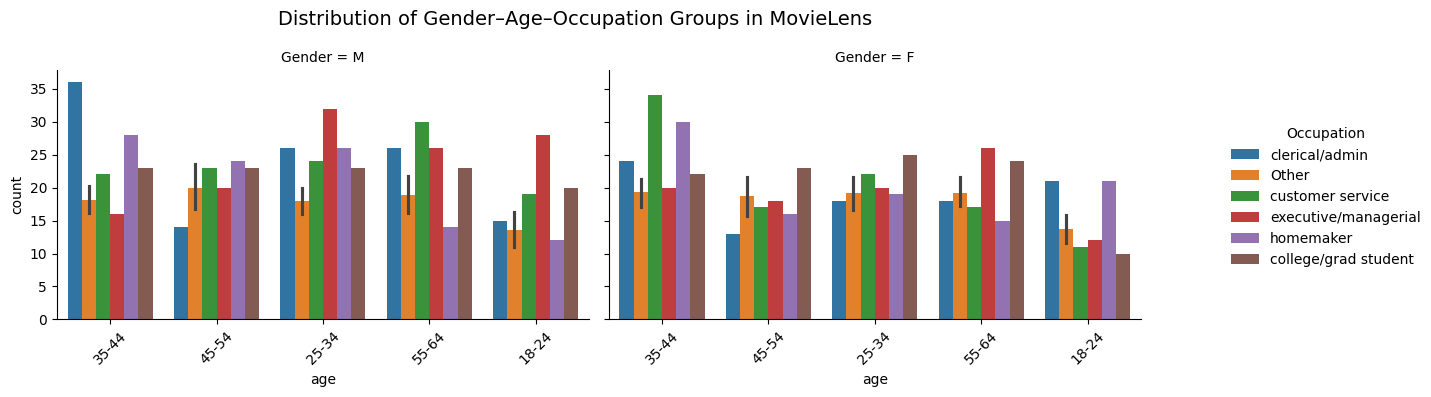

In [90]:
# distribution 
counts = group_counts.reset_index(name="count")
top_occ = (
    counts.groupby("occupation")["count"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

counts["occupation_plot"] = counts["occupation"].where(
    counts["occupation"].isin(top_occ), "Other"
)

g = sns.catplot(
    data=counts,
    x="age",
    y="count",
    hue="occupation_plot",
    col="gender",
    kind="bar",
    height=4,
    aspect=1.2
)

g.set_xticklabels(rotation=45)
g.set_titles("Gender = {col_name}")
leg = g._legend
leg.set_title("Occupation")
leg.set_bbox_to_anchor((1.05, 0.5))
leg.set_loc("center left")
g.fig.suptitle(
    "Distribution of Gender–Age–Occupation Groups in MovieLens",
    fontsize=14)
plt.tight_layout()
plt.show()

In [55]:
# distributions of calibration and test sets to show the effect of stratification
print("Number of calibration samples:", len(ml_train))
print("Number of test samples:", len(ml_test))


Number of calibration samples: 1729
Number of test samples: 741


In [35]:
def group_proportions(df, split_name):
    out = (
        df[["gender", "age", "occupation"]]
        .value_counts()
        .reset_index(name="count")
    )
    out["prop"] = out["count"] / out["count"].sum() # number of samples in group / number of samples in split
    out["split"] = split_name
    return out

train_groups  = group_proportions(ml_train, "Calibration")
test_groups = group_proportions(ml_test, "Test")

plot_df = pd.concat([train_groups, test_groups], ignore_index=True)
plot_df.head()


,gender,age,occupation,count,prop,split
0,M,18-24,college/grad student,106,0.061307,Calibration
1,M,25-34,other,83,0.048005,Calibration
2,M,25-34,executive/managerial,62,0.035859,Calibration
3,M,25-34,college/grad student,55,0.031810,Calibration
4,M,25-34,programmer,52,0.030075,Calibration


In [ ]:
plot_df_age = (
    plot_df
    .groupby(["gender", "age", "split"], as_index=False)["prop"]
    .sum()
)

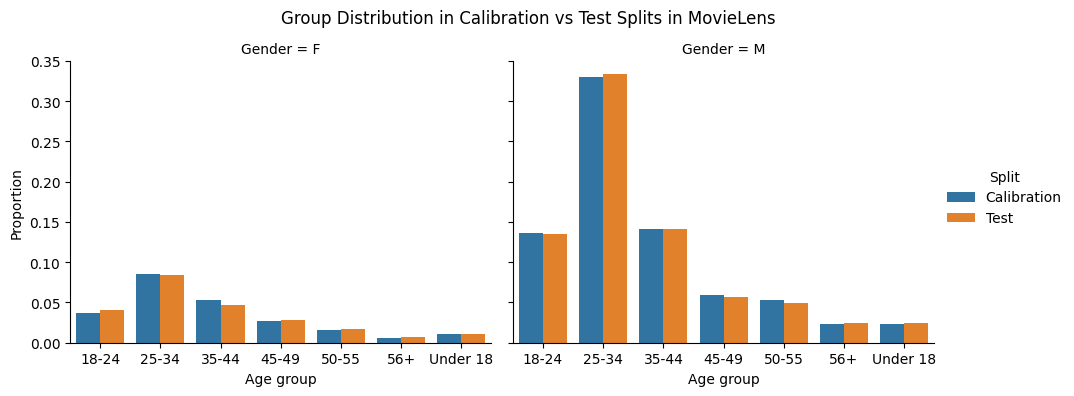

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.catplot(
    data=plot_df_age,
    x="age",
    y="prop",
    hue="split",
    col="gender",
    kind="bar",
    height=4,
    aspect=1.2
)

g.set_titles("Gender = {col_name}")
g.set_axis_labels("Age group", "Proportion")
g._legend.set_title("Split")

g.fig.suptitle("Group Distribution in Calibration vs Test Splits in MovieLens")
g.fig.subplots_adjust(top=0.85)

plt.show()


### Dataset: Amazon

In [63]:
# Full Dataset
logger = setup_logging()
loader = DatasetLoader('amazon')
full_am = loader.prepare_prompts().dropna().reset_index(drop=True)

2026-01-22 16:58:35,151 - INFO - Amazon reviews already downloaded.
2026-01-22 16:58:35,151 - INFO - Amazon metadata already downloaded.
Loading Amazon data: 3410019it [00:23, 146364.77it/s]
Loading Amazon metadata: 203766it [00:01, 117247.81it/s]
Building sequences (amazon): 100%|██████████| 295218/295218 [00:34<00:00, 8674.70it/s] 


In [64]:
# Number of samples in full Amazon
len(full_am)

808669

In [65]:
full_am.head()

,prompt,context,gender,age,occupation,target_mid,target_title
0,User profile (audit only):\n- gender: M\n- age...,Watch history:\n1. Grimm\n2. Intolerable Cruel...,M,55-64,farmer,B005LAJ1LS,Bored to Death: Season 3
1,User profile (audit only):\n- gender: M\n- age...,Watch history:\n1. Intolerable Cruelty\n2. Fra...,M,55-64,farmer,6303574289,"Star Trek - The Next Generation, Episode 74: T..."
2,User profile (audit only):\n- gender: M\n- age...,Watch history:\n1. Frasier: Season 10\n2. Fras...,M,55-64,farmer,B000063V8R,Star Trek The Next Generation - The Complete T...
3,User profile (audit only):\n- gender: M\n- age...,Watch history:\n1. Frasier - The Complete Fina...,M,55-64,farmer,B00NC61CSS,A Merry Friggin' Christmas [Blu-ray]
4,User profile (audit only):\n- gender: M\n- age...,Watch history:\n1. Frasier: Season 1\n2. Frasi...,M,55-64,farmer,B000063V8T,Star Trek The Next Generation - The Complete F...


In [66]:
# Number of target titles in the full Amazon
len(full_am['target_title'].drop_duplicates())

54470

In [70]:
# Sampled dataset
am = pd.read_csv('data_preprocessed/amazon_3750.csv')
am_train = pd.read_csv('data_preprocessed/amazon_3750_train.csv')
am_test = pd.read_csv('data_preprocessed/amazon_3750_test.csv')

In [71]:
am.head()

,prompt,context,gender,age,occupation,target_mid,target_title
0,User profile (audit only):\n- gender: F\n- age...,Watch history:\n1. The Vow\n2. Wall-E (Mandari...,F,25-34,customer service,B00DL47KWI,Girl Most Likely
1,User profile (audit only):\n- gender: M\n- age...,Watch history:\n1. The Hunger Games (2 Disc) [...,M,45-54,retired,B00683T51S,Journey 2: The Mysterious Island
2,User profile (audit only):\n- gender: F\n- age...,Watch history:\n1. Mr Smith Goes to Washington...,F,35-44,retired,630020779X,Adventures of Captain Fabian VHS
3,User profile (audit only):\n- gender: M\n- age...,Watch history:\n1. TCM on Moonlight Bay / By t...,M,45-54,lawyer,B002OOWKXA,Adam-12
4,User profile (audit only):\n- gender: F\n- age...,Watch history:\n1. The Eagle\n2. The Best Exot...,F,45-54,other,B000WLYDNM,Mongol: The Early Years of Genghis Khan


In [72]:
# number of female users in Amazon
print('number of female users:', len(am[am['gender']=='F']))
print('number of male users:', len(am[am['gender']=='M']))


number of female users: 1848
number of male users: 1902


In [73]:
# number of distinct of occupations
print(len(list(am['occupation'].drop_duplicates())))

20


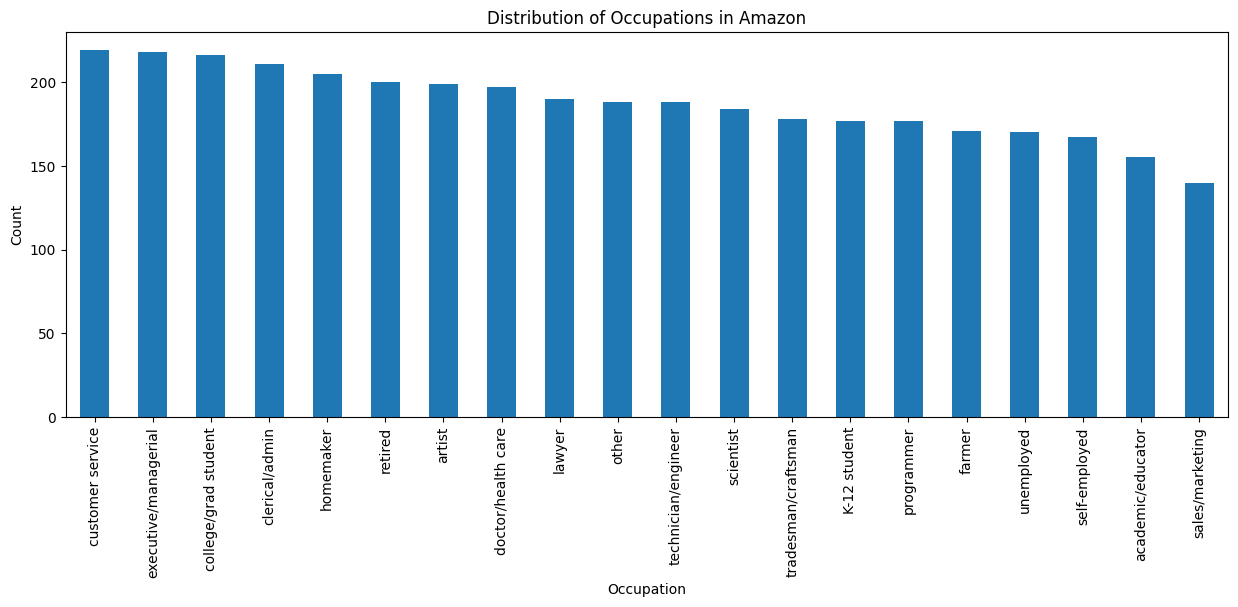

In [74]:
# Bar plot of occupations
counts = am["occupation"].value_counts()
plt.figure(figsize=(15,5))
counts.plot(kind='bar')
plt.xlabel("Occupation")
plt.ylabel("Count")
plt.title("Distribution of Occupations in Amazon")
plt.show()

In [ ]:
# number of distinct target titles in Amazon sampled
print(len(list(am['target_title'].drop_duplicates())))

3120


In [91]:
# number of unique combinations gender-age-occupation
group_counts_am = am[['gender', 'age', 'occupation']].value_counts()
group_counts_am

gender  age    occupation          
M       35-44  clerical/admin          36
        45-54  doctor/health care      35
F       35-44  customer service        34
        45-54  technician/engineer     32
M       25-34  executive/managerial    32
                                       ..
        55-64  retired                  8
F       18-24  programmer               8
        25-34  academic/educator        8
        18-24  sales/marketing          7
M       18-24  tradesman/craftsman      5
Name: count, Length: 200, dtype: int64

In [93]:
# number of unique combinations gender-age-occupation in calibration set
group_counts_train = am_train[['gender', 'age', 'occupation']].value_counts()
len(group_counts_train)

200

In [92]:
# number of unique combinations gender-age-occupation in test set
group_counts_test = am_test[['gender', 'age', 'occupation']].value_counts()
len(group_counts_test)

200

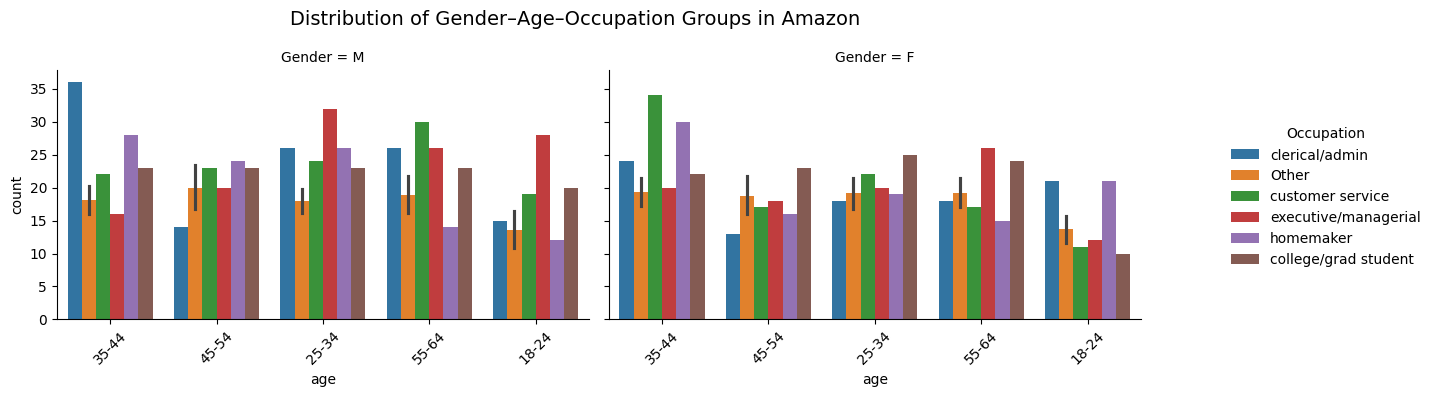

In [94]:
# distribution 
counts = group_counts_am.reset_index(name="count")
top_occ = (
    counts.groupby("occupation")["count"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

counts["occupation_plot"] = counts["occupation"].where(
    counts["occupation"].isin(top_occ), "Other"
)

g = sns.catplot(
    data=counts,
    x="age",
    y="count",
    hue="occupation_plot",
    col="gender",
    kind="bar",
    height=4,
    aspect=1.2
)

g.set_xticklabels(rotation=45)
g.set_titles("Gender = {col_name}")
leg = g._legend
leg.set_title("Occupation")
leg.set_bbox_to_anchor((1.05, 0.5))
leg.set_loc("center left")
g.fig.suptitle(
    "Distribution of Gender–Age–Occupation Groups in Amazon",
    fontsize=14)
plt.tight_layout()
plt.show()

In [85]:
# distributions of calibration and test sets to show the effect of stratification
print("Number of calibration samples:", len(am_train))
print("Number of test samples:", len(am_test))


Number of calibration samples: 2625
Number of test samples: 1125


In [86]:
train_groups_am  = group_proportions(am_train, "Calibration")
test_groups_am = group_proportions(am_test, "Test")

plot_df_am = pd.concat([train_groups_am, test_groups_am], ignore_index=True)
plot_df_am.head()

,gender,age,occupation,count,prop,split
0,M,35-44,clerical/admin,25,0.009524,Calibration
1,M,45-54,doctor/health care,25,0.009524,Calibration
2,F,35-44,customer service,24,0.009143,Calibration
3,M,25-34,executive/managerial,22,0.008381,Calibration
4,M,55-64,self-employed,22,0.008381,Calibration


In [87]:
plot_df_age_am = (
    plot_df_am
    .groupby(["gender", "age", "split"], as_index=False)["prop"]
    .sum()
)

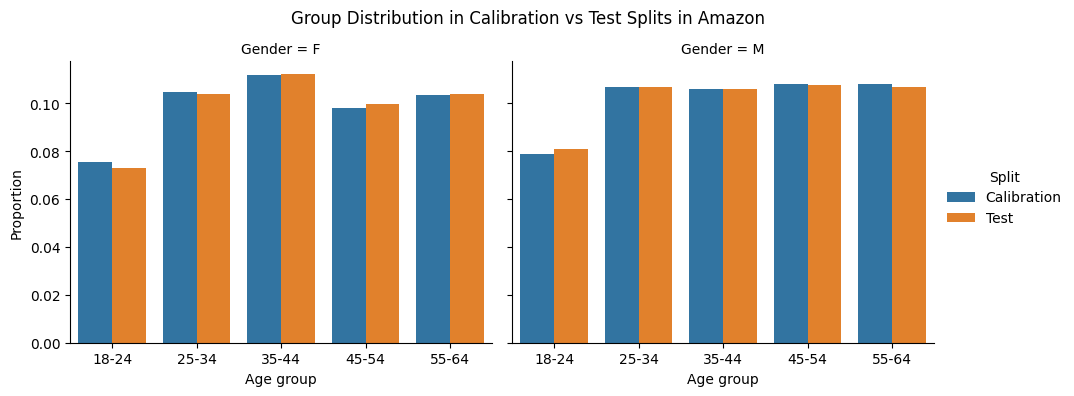

In [88]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.catplot(
    data=plot_df_age_am,
    x="age",
    y="prop",
    hue="split",
    col="gender",
    kind="bar",
    height=4,
    aspect=1.2
)

g.set_titles("Gender = {col_name}")
g.set_axis_labels("Age group", "Proportion")
g._legend.set_title("Split")

g.fig.suptitle("Group Distribution in Calibration vs Test Splits in Amazon")
g.fig.subplots_adjust(top=0.85)

plt.show()
